In [1]:
#---1. Khai báo & thiết lập hệ thống---
from __future__ import annotations
from pathlib import Path
from typing import List, Tuple

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Thư viện thuật toán Association Rules
try:
    from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
except ImportError:
    # Gợi ý cài đặt nếu thiếu
    print("Thiếu mlxtend. Đang cố gắng cài đặt hoặc hãy chạy: pip install mlxtend")
    raise ImportError("Thiếu mlxtend.")

# --- CẤU HÌNH HIỂN THỊ & HIỆU NĂNG ---
plt.rcParams["figure.figsize"] = (12, 6)
sns.set_theme(style="whitegrid")

# Cấu hình Polars để xem dữ liệu lớn dễ dàng hơn
pl.Config.set_tbl_rows(15)
pl.Config.set_tbl_cols(15)
pl.Config.set_fmt_str_lengths(50) # Không cắt ngắn ID khách hàng quá nhiều

class W3Config:
    # 1. Tự động xác định BASE_DIR để tránh lỗi khi chạy ở các thư mục khác nhau
    BASE_DIR = Path(".").resolve()
    OUTPUT_DIR = BASE_DIR / "outputs"

    # 2. Các file dữ liệu nguồn (Đầu vào)
    TRANSACTIONS_CSV  = BASE_DIR / "transactions_train.csv"
    CUSTOMERS_CLEAN   = OUTPUT_DIR / "customers_clean.parquet"
    ARTICLES_CLEAN    = OUTPUT_DIR / "articles_clean.parquet"
    CUSTOMER_SEGMENTS = OUTPUT_DIR / "customer_segments_final.parquet"

    # 3. Các file kết quả Tuần 3 (Đầu ra)
    BASKETS_PARQUET              = OUTPUT_DIR / "transaction_baskets.parquet"
    CHAMPION_RULES_PARQUET       = OUTPUT_DIR / "champion_association_rules.parquet"
    CLUSTER_TOP_PRODUCTS_PARQUET = OUTPUT_DIR / "cluster_top_products.parquet"
    RECOMMENDATIONS_PARQUET      = OUTPUT_DIR / "customer_recommendations.parquet"

    @classmethod
    def setup(cls):
        """Tạo thư mục và kiểm tra file nguồn để tránh lỗi giữa chừng."""
        cls.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

        # Kiểm tra xem các file từ Tuần 1 & 2 đã tồn tại chưa
        inputs = [cls.CUSTOMERS_CLEAN, cls.ARTICLES_CLEAN, cls.CUSTOMER_SEGMENTS]
        for f in inputs:
            if not f.exists():
                print(f"Cảnh báo: Không tìm thấy {f.name} tại {f.parent}. "
                      f"Hãy đảm bảo đã có kết quả tuần 1 & 2 vào thư mục outputs!")

# Thực thi cấu hình
W3Config.setup()

In [2]:

#---2. Nạp dữ liệu đầu vào---

# Quét giao dịch (Lazy): Chỉ lấy những cột thực sự cần cho Basket & Rules. Việc loại bỏ các cột không dùng (như sales_channel_id) giúp tiết kiệm rất nhiều RAM
transactions_lf = (
    pl.scan_csv(
        W3Config.TRANSACTIONS_CSV,
        schema_overrides={
            "customer_id": pl.Utf8,
            "article_id": pl.Int32,
            "price": pl.Float32,
        },
        try_parse_dates=True,
        infer_schema_length=10000,
        low_memory=True,
    )
    .select(["t_dat", "customer_id", "article_id", "price"]) # Chỉ lấy cột cần thiết
    .with_columns([
        pl.col("t_dat").cast(pl.Date, strict=False),
        pl.col("customer_id").str.strip_chars(), # Đảm bảo không có khoảng trắng thừa gây lỗi join
    ])
)

# Nạp các bảng Parquet sạch (Đã đồng nhất kiểu dữ liệu với Transactions). Ép kiểu String (Utf8) ngay từ đầu để các phép Join sau này không bị lệch Schema
customers_clean = pl.read_parquet(W3Config.CUSTOMERS_CLEAN).select(["customer_id", "club_member_status"])

articles_clean = pl.read_parquet(W3Config.ARTICLES_CLEAN).select(["article_id", "prod_name", "product_group_name"])

segments = pl.read_parquet(W3Config.CUSTOMER_SEGMENTS).with_columns([
    pl.col("customer_id").cast(pl.Utf8).str.strip_chars(),
    pl.col("Cluster").cast(pl.Int8) # Ép kiểu Int8 cho Cluster để tiết kiệm bộ nhớ
])

print(f" Đã nạp xong: {customers_clean.height:,} Customers, {articles_clean.height:,} Articles.")
print(f" Đã nạp bảng Segments: {segments.height:,} khách hàng phân cụm.")

display(segments.head())

 Đã nạp xong: 1,371,980 Customers, 105,542 Articles.
 Đã nạp bảng Segments: 837,609 khách hàng phân cụm.


customer_id,recency,frequency,monetary,recency_log,frequency_log,monetary_log,recency_scaled,frequency_scaled,monetary_scaled,Cluster
str,i64,u32,f32,f64,f64,f32,f64,f64,f64,i8
"""8f2918d61f38fcb9fd4ad84fddd954abde0a6752d0735c5794…",57,10,0.265932,4.060443,2.397895,0.235809,0.119504,0.302665,-0.037763,0
"""d955df3c0ac82288ed2f641f3d855e25399f7dc616569b0fce…",68,2,0.067763,4.234107,1.098612,0.065566,0.264899,-1.092486,-0.704836,1
"""49ee44292aa0b62b2e2217e26dbdedda4502f362bce73fdb32…",237,1,0.022017,5.472271,0.693147,0.021778,1.301519,-1.527868,-0.876411,1
"""2a004087173ce3927180152433fba487c0e42963649845ff14…",218,1,0.022017,5.389072,0.693147,0.021778,1.231862,-1.527868,-0.876411,1
"""5cf180e2f35b6303d8c4b3977b037fb2984849332b44eb88ad…",67,22,0.437508,4.219508,3.135494,0.362911,0.252677,1.094688,0.46027,0


In [3]:

#---3. Kiểm tra và Chuẩn hóa Schema Segmentation---

# Danh sách cột bắt buộc phải có từ Tuần 2
required_cols = ["customer_id", "Cluster", "recency", "frequency", "monetary"]
missing_cols = [c for c in required_cols if c not in segments.columns]

if missing_cols:
    raise ValueError(f" Lỗi: File segmentation thiếu các cột: {missing_cols}. Hãy kiểm tra lại kết quả Tuần 2!")

# Tối ưu: Ép kiểu dữ liệu đồng nhất để tránh lỗi Join Keys mismatch
# Ép customer_id về String và Cluster về Int để tiết kiệm RAM
segments = segments.select(required_cols).with_columns([
    pl.col("customer_id").cast(pl.Utf8).str.strip_chars(),
    pl.col("Cluster").cast(pl.Int8),
    pl.col("recency").cast(pl.Int32),
    pl.col("frequency").cast(pl.Int32),
    pl.col("monetary").cast(pl.Float32),
])

print(f" Schema hợp lệ. Đang xử lý {segments.height:,} khách hàng đã phân cụm.")
display(segments.head())


 Schema hợp lệ. Đang xử lý 837,609 khách hàng đã phân cụm.


customer_id,Cluster,recency,frequency,monetary
str,i8,i32,i32,f32
"""8f2918d61f38fcb9fd4ad84fddd954abde0a6752d0735c5794…",0,57,10,0.265932
"""d955df3c0ac82288ed2f641f3d855e25399f7dc616569b0fce…",1,68,2,0.067763
"""49ee44292aa0b62b2e2217e26dbdedda4502f362bce73fdb32…",1,237,1,0.022017
"""2a004087173ce3927180152433fba487c0e42963649845ff14…",1,218,1,0.022017
"""5cf180e2f35b6303d8c4b3977b037fb2984849332b44eb88ad…",0,67,22,0.437508


In [4]:


#---4. Gán tên hành vi cho từng cụm---
# Tính toán Profile cho từng cụm để nhận diện nhãn
cluster_profile = (
    segments.group_by("Cluster")
    .agg([
        pl.col("recency").mean().alias("avg_recency"),
        pl.col("frequency").mean().alias("avg_frequency"),
        pl.col("monetary").mean().alias("avg_monetary"),
        pl.len().alias("num_customers")
    ])
    .sort("Cluster")
)

# Chuyển sang Pandas để xử lý logic định danh persona
profile_pd = cluster_profile.to_pandas()

# Thuật toán tự động nhận diện ID của từng nhóm
# Nhóm Champions: Mua gần đây nhất (recency min) và tiêu nhiều nhất
champion_id = profile_pd.sort_values(
    ["avg_recency", "avg_monetary"], ascending=[True, False]
).iloc[0]["Cluster"]

# Nhóm Hibernating: Đã lâu nhất chưa quay lại (recency max)
hibernating_id = profile_pd.sort_values(
    "avg_recency", ascending=False
).iloc[0]["Cluster"]

# Nhóm New Customers: Mới mua (recency thấp) nhưng tần suất mua ít
# Lọc bỏ 2 nhóm trên trước khi tìm
remaining = profile_pd[~profile_pd["Cluster"].isin([champion_id, hibernating_id])]
new_cust_id = remaining.sort_values(
    ["avg_recency", "avg_frequency"], ascending=[True, True]
).iloc[0]["Cluster"]

# Tạo Mapping Dictionary từ kết quả tính toán
# Các cụm còn lại mặc định là Loyalists
cluster_name_map = {c: "Loyalists" for c in profile_pd["Cluster"]}
cluster_name_map[champion_id] = "Champions"
cluster_name_map[hibernating_id] = "Hibernating"
cluster_name_map[new_cust_id] = "New Customers"

print(" Kết quả nhận diện cụm tự động:", cluster_name_map)

# Áp dụng nhãn vào bảng Segments bằng phép Join thay vì gán cứng
mapping_df = pl.DataFrame({
    "Cluster": list(cluster_name_map.keys()),
    "Cluster_Name": list(cluster_name_map.values())
}).with_columns(pl.col("Cluster").cast(pl.Int8))

segments_named = segments.join(mapping_df, on="Cluster", how="left")

# Kiểm tra kết quả
display(segments_named.group_by("Cluster_Name").agg(pl.len()).sort("len", descending=True))


 Kết quả nhận diện cụm tự động: {0: 'Loyalists', 1: 'Hibernating', 2: 'New Customers', 3: 'Champions'}


Cluster_Name,len
str,u32
"""Hibernating""",367092
"""Loyalists""",242301
"""Champions""",134121
"""New Customers""",94095


In [5]:


#---5. Join transactions với segmentation (Tối ưu bộ nhớ)---


# Chuyển bảng segments_named sang Lazy để tối ưu hóa kế hoạch thực thi (Query Plan)
segments_lazy = segments_named.lazy().select(["customer_id", "Cluster", "Cluster_Name"])

# Thực hiện phép Join: Sử dụng LazyFrame giúp Polars chỉ nạp những dữ liệu cần thiết vào RAM khi gọi .collect()
tx_cluster_lf = (
    transactions_lf
    .join(
        segments_lazy,
        on="customer_id",
        how="inner"
    )
    # Loại bỏ các dòng có giá trị Null nếu khách hàng không nằm trong danh sách phân cụm
    .drop_nulls(subset=["Cluster_Name"])
)

# Kiểm tra kết quả (Chỉ lấy 5 dòng để xem nhanh, tránh load toàn bộ)
print("--- Xem trước dữ liệu sau khi Join ---")
display(
    tx_cluster_lf.select([
        "customer_id", "t_dat", "article_id", "price", "Cluster_Name"
    ])
    .limit(5)
    .collect()
)

# Kiểm tra phân bổ giao dịch theo từng cụm (Quan trọng để kiểm tra tính logic)
print("\n--- Thống kê số lượng giao dịch theo cụm ---")
display(
    tx_cluster_lf.group_by("Cluster_Name")
    .agg(pl.len().alias("transaction_count"))
    .collect()
)

--- Xem trước dữ liệu sau khi Join ---


customer_id,t_dat,article_id,price,Cluster_Name
str,date,i32,f32,str
"""000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ff…",2018-09-20,663713001,0.050831,"""Champions"""
"""000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ff…",2018-09-20,541518023,0.030492,"""Champions"""
"""00007d2de826758b65a93dd24ce629ed66842531df6699338c…",2018-09-20,505221004,0.015237,"""Loyalists"""
"""00007d2de826758b65a93dd24ce629ed66842531df6699338c…",2018-09-20,685687003,0.016932,"""Loyalists"""
"""00007d2de826758b65a93dd24ce629ed66842531df6699338c…",2018-09-20,685687004,0.016932,"""Loyalists"""



--- Thống kê số lượng giao dịch theo cụm ---


Cluster_Name,transaction_count
str,u32
"""Hibernating""",4308802
"""Champions""",3398291
"""Loyalists""",9165901
"""New Customers""",10811945


In [6]:


#---6. Xây dựng transaction basket (Tối ưu Streaming & Memory) ---

# Định nghĩa logic gom nhóm giỏ hàng: Sử dụng LazyFrame để tối ưu hóa việc đọc/ghi
baskets_lf = (
    tx_cluster_lf
    .group_by(["customer_id", "t_dat", "Cluster_Name"])
    .agg([
        # Lấy danh sách article_id duy nhất trong cùng 1 ngày của 1 khách
        pl.col("article_id").unique().alias("basket_articles"),
        # Tính quy mô giỏ hàng
        pl.len().alias("basket_size"),
        # Tổng giá trị giỏ hàng
        pl.col("price").sum().alias("basket_value")
    ])
    # TỐI ƯU: Chỉ giữ lại các giỏ hàng có từ 2 sản phẩm trở lên: Vì Association Rules (Apriori) không thể tìm luật từ giỏ hàng chỉ có 1 món
    .filter(pl.col("basket_size") >= 2)
)

# Thực thi với chế độ STREAMING: Chế độ này giúp Polars xử lý dữ liệu theo từng phần, không nạp tất cả vào RAM cùng lúc
print("--- Đang xây dựng giỏ hàng (Chế độ Streaming)... ---")
baskets = baskets_lf.collect(streaming=True)

print(f"Đã tạo xong {baskets.height:,} giỏ hàng chất lượng (size >= 2).")
display(baskets.head())

# Lưu kết quả
baskets.write_parquet(W3Config.BASKETS_PARQUET)
print(f"Đã lưu file basket tại: {W3Config.BASKETS_PARQUET}")

--- Đang xây dựng giỏ hàng (Chế độ Streaming)... ---


C:\Users\Admin\AppData\Local\Temp\ipykernel_2100\3265766911.py:21: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  baskets = baskets_lf.collect(streaming=True)


Đã tạo xong 5,568,747 giỏ hàng chất lượng (size >= 2).


customer_id,t_dat,Cluster_Name,basket_articles,basket_size,basket_value
str,date,str,list[i32],u32,f32
"""9754c08c71b69989a0d6e80ac397965c169a553bea87b99c1c…",2020-08-07,"""New Customers""",[915467002],2,0.169458
"""37b0e6e26a268ef32f2acb929d5dabea14d06c7d5f0ed43ad8…",2018-09-21,"""Hibernating""","[667499001, 522398052, 589924010]",3,0.067746
"""679c9670698f0aa5de9fb96e12d79cbf8d581038c1c3bd50de…",2019-06-04,"""New Customers""","[718902001, 718908001, … 718202001]",11,0.248966
"""242580d366a4a95e38d2db5070d7d5c6e82dd03b7b557cc5f2…",2018-12-06,"""Hibernating""","[625568003, 705330001]",2,0.091492
"""3e1a55c40838543726c0854dda9a95bd04919ae5bb9768884b…",2020-03-07,"""Loyalists""","[760084006, 186262001, … 822238001]",4,0.077051


Đã lưu file basket tại: C:\Users\Admin\PycharmProjects\PythonProject1\outputs\transaction_baskets.parquet


In [7]:


#---7 & 8. Lọc baskets Champions & Giảm chiều sản phẩm (Tối ưu Speed)---

# Lọc riêng baskets của Champions (Dùng lại biến baskets đã collect từ bước 6)
champion_baskets = baskets.filter(pl.col("Cluster_Name") == "Champions")
print(f"--- Số lượng giỏ hàng Champions ban đầu: {champion_baskets.height:,} ---")

# Tìm Top N sản phẩm phổ biến nhất trong nhóm Champions
TOP_N_RULE_PRODUCTS = 150

# Tối ưu: Tính tần suất sản phẩm nhanh bằng explode
champion_item_freq = (
    champion_baskets
    .select("basket_articles")
    .explode("basket_articles")
    .group_by("basket_articles")
    .agg(pl.len().alias("freq"))
    .sort("freq", descending=True)
)

top_rule_products = champion_item_freq.head(TOP_N_RULE_PRODUCTS)["basket_articles"].to_list()
top_rule_products_set = set(top_rule_products) # Dùng set để tìm kiếm nhanh hơn O(1)

# Lọc giỏ hàng: Chỉ giữ lại các sản phẩm nằm trong Top N
# Tối ưu logic: Loại bỏ các sản phẩm "nhiễu" khỏi giỏ hàng
champion_baskets_filtered = (
    champion_baskets
    .with_columns([
        pl.col("basket_articles")
        .list.eval(pl.element().filter(pl.element().is_in(top_rule_products)))
        .alias("basket_articles")
    ])
    .with_columns([
        pl.col("basket_articles").list.len().alias("filtered_basket_size")
    ])
    # Quan trọng: Sau khi lọc sản phẩm nhiễu, giỏ hàng phải còn ít nhất 2 món mới dùng được
    .filter(pl.col("filtered_basket_size") >= 2)
    .drop("filtered_basket_size")
)

print(f" Số lượng giỏ hàng Champions sau khi lọc Top {TOP_N_RULE_PRODUCTS}: {champion_baskets_filtered.height:,}")
display(champion_baskets_filtered.head())

--- Số lượng giỏ hàng Champions ban đầu: 800,208 ---
 Số lượng giỏ hàng Champions sau khi lọc Top 150: 26,748


customer_id,t_dat,Cluster_Name,basket_articles,basket_size,basket_value
str,date,str,list[i32],u32,f32
"""eca11279e45ea3d20e4e933ff0cf299713baecb08a8bde52f0…",2019-04-18,"""Champions""","[706016003, 706016002]",8,0.227695
"""50bfb6c8f5ce44f86d068edbaf2b5454bfc859b0ff871720b3…",2018-12-01,"""Champions""","[160442007, 160442010]",5,0.091441
"""65f8423a8697077867a6c9f0b3b0fa05a5ccf49c00ccddacd6…",2019-12-06,"""Champions""","[156231001, 297067002]",3,0.022847
"""2c876705601bd9f799305d22b5c9a8b62850646400b9cafb31…",2020-06-12,"""Champions""","[741356002, 554479001]",10,0.259153
"""e33a5209ea061e16b41db1545c98a5a09899ca91f40004662a…",2018-12-29,"""Champions""","[436261001, 297067002]",3,0.02878


In [8]:


#---9 & 10. One-hot Matrix & Association Rules (Tối ưu bộ nhớ & Tốc độ)---

from mlxtend.preprocessing import TransactionEncoder

# Chuyển đổi dữ liệu sang định dạng One-hot Matrix
# Tối ưu: TransactionEncoder nhanh hơn và ít tốn RAM hơn việc tạo DataFrame bằng Dictionary
te = TransactionEncoder()
print("--- Đang mã hóa giỏ hàng sang ma trận One-hot... ---")

# Lấy danh sách các giỏ hàng (list of lists)
dataset = champion_baskets_filtered["basket_articles"].to_list()

# Encode và chuyển về DataFrame (Sparse format nếu cần)
te_ary = te.fit(dataset).transform(dataset)
basket_matrix = pd.DataFrame(te_ary, columns=te.columns_)

print(f" Ma trận One-hot hoàn tất. Kích thước: {basket_matrix.shape}")

# Chạy thuật toán tìm tập mục phổ biến (Frequent Itemsets)
# MẸO: Nếu Apriori vẫn chậm, bạn có thể thay bằng fpgrowth (nhanh hơn rất nhiều)
MIN_SUPPORT = 0.003

print(f"--- Đang tìm tập mục phổ biến (Min Support: {MIN_SUPPORT})... ---")
frequent_itemsets = apriori(
    basket_matrix,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    low_memory=True # Tiết kiệm RAM khi tính toán
)

# Tạo luật kết hợp (Association Rules)
MIN_CONFIDENCE = 0.10
MIN_LIFT = 1.05

if not frequent_itemsets.empty:
    print(f"--- Đang trích xuất luật kết hợp (Min Conf: {MIN_CONFIDENCE})... ---")
    rules = association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=MIN_CONFIDENCE
    )

    # Lọc theo Lift và sắp xếp để lấy những luật mạnh nhất
    rules = rules[rules["lift"] >= MIN_LIFT].copy()
    rules = rules.sort_values(["lift", "confidence"], ascending=False)

    print(f" Đã tìm thấy {len(rules)} luật kết hợp cho nhóm Champions.")
    display(rules.head(10))
else:
    print(" Không tìm thấy tập mục nào thỏa mãn Min Support. Hãy thử giảm MIN_SUPPORT.")
    rules = pd.DataFrame()


--- Đang mã hóa giỏ hàng sang ma trận One-hot... ---
 Ma trận One-hot hoàn tất. Kích thước: (26748, 150)
--- Đang tìm tập mục phổ biến (Min Support: 0.003)... ---
--- Đang trích xuất luật kết hợp (Min Conf: 0.1)... ---
 Đã tìm thấy 106 luật kết hợp cho nhóm Champions.


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
27,frozenset({564786001}),frozenset({484398001}),0.007029,0.008561,0.003215,0.457447,53.431385,1.0,0.003155,1.827357,0.988230,0.259819,0.452762,0.416496
28,frozenset({484398001}),frozenset({564786001}),0.008561,0.007029,0.003215,0.375546,53.431385,1.0,0.003155,1.590143,0.989758,0.259819,0.371126,0.416496
29,frozenset({539723001}),frozenset({539723005}),0.008225,0.009683,0.003926,0.477273,49.289926,1.0,0.003846,1.894520,0.987837,0.280749,0.472162,0.441339
30,frozenset({539723005}),frozenset({539723001}),0.009683,0.008225,0.003926,0.405405,49.289926,1.0,0.003846,1.667985,0.989291,0.280749,0.400474,0.441339
67,frozenset({685816002}),frozenset({685816001}),0.013982,0.011889,0.007963,0.569519,47.904046,1.0,0.007797,2.295364,0.993010,0.444676,0.564339,0.619665
66,frozenset({685816001}),frozenset({685816002}),0.011889,0.013982,0.007963,0.669811,47.904046,1.0,0.007797,2.986225,0.990906,0.444676,0.665129,0.619665
35,frozenset({554479005}),frozenset({554479001}),0.011253,0.011291,0.005944,0.528239,46.785901,1.0,0.005817,2.095785,0.989764,0.358108,0.522852,0.527365
34,frozenset({554479001}),frozenset({554479005}),0.011291,0.011253,0.005944,0.526490,46.785901,1.0,0.005817,2.088123,0.989801,0.358108,0.521101,0.527365
92,frozenset({749699001}),frozenset({749699002}),0.012375,0.011477,0.006393,0.516616,45.011248,1.0,0.006251,2.045006,0.990035,0.366167,0.511004,0.536810
93,frozenset({749699002}),frozenset({749699001}),0.011477,0.012375,0.006393,0.557003,45.011248,1.0,0.006251,2.229419,0.989136,0.366167,0.551453,0.536810


TOP 10 LUẬT KẾT HỢP (DỰA TRÊN TÊN SẢN PHẨM):


,antecedents_name,consequents_name,support,confidence,lift
0,karin sports bra,supreme tights,0.003215,0.457447,53.431385
1,supreme tights,karin sports bra,0.003215,0.375546,53.431385
2,jade denim trs,jade denim trs,0.003926,0.477273,49.289926
3,jade denim trs,jade denim trs,0.003926,0.405405,49.289926
4,ronny reg rn t-shirt,ronny reg rn t-shirt,0.007963,0.569519,47.904046
5,ronny reg rn t-shirt,ronny reg rn t-shirt,0.007963,0.669811,47.904046
6,ozzy denim shorts,ozzy denim shorts,0.005944,0.528239,46.785901
7,ozzy denim shorts,ozzy denim shorts,0.005944,0.526490,46.785901
8,chestnut strap top,chestnut strap top,0.006393,0.516616,45.011248
9,chestnut strap top,chestnut strap top,0.006393,0.557003,45.011248


C:\Users\Admin\AppData\Local\Temp\ipykernel_2100\4189074596.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_plot, x='confidence', y='rule_label', ax=axes[0], palette='viridis')
C:\Users\Admin\AppData\Local\Temp\ipykernel_2100\4189074596.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_plot, x='lift', y='rule_label', ax=axes[1], palette='magma')


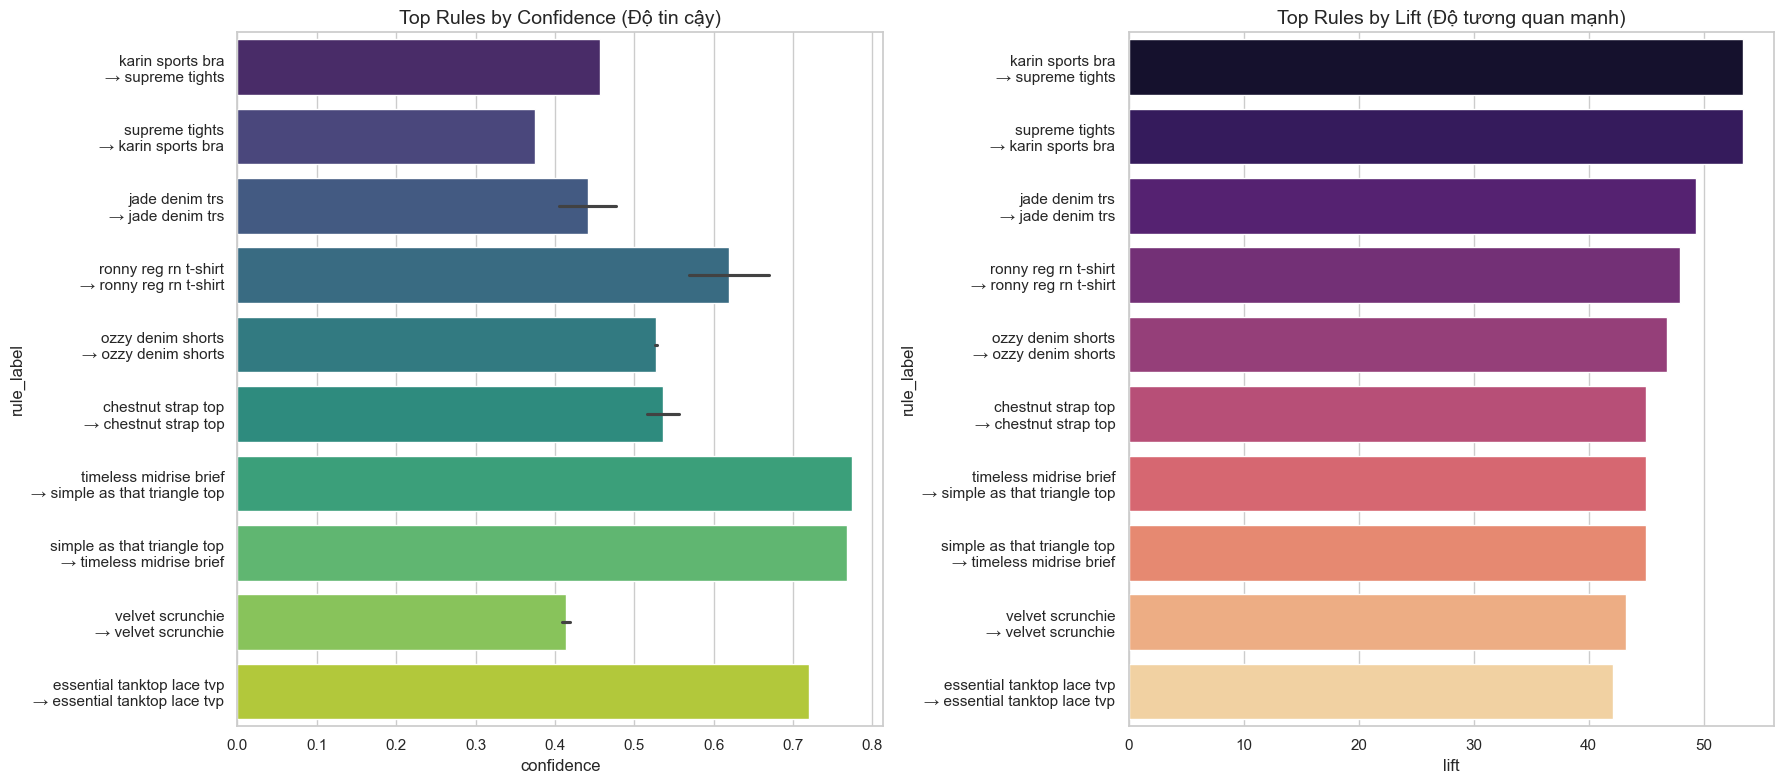

In [9]:


#---11 & 12. Làm đẹp & Trực quan hóa Luật kết hợp (Thêm tên sản phẩm)---

if len(rules) > 0:
    # Tạo từ điển ánh xạ ID -> Tên sản phẩm để dễ đọc
    # articles_clean đã được nạp ở bước 2
    id_to_name = dict(zip(articles_clean["article_id"], articles_clean["prod_name"]))

    def get_names(ids_frozenset):
        names = [id_to_name.get(int(i), str(i)) for i in ids_frozenset]
        return ", ".join(sorted(names))

    # Làm đẹp bảng hiển thị
    rules_display = rules.copy()
    rules_display["antecedents_name"] = rules_display["antecedents"].apply(get_names)
    rules_display["consequents_name"] = rules_display["consequents"].apply(get_names)

    # Giữ lại cả ID và Tên để kiểm tra
    rules_final = rules_display[[
        "antecedents_name", "consequents_name", "support", "confidence", "lift"
    ]].reset_index(drop=True)

    print("TOP 10 LUẬT KẾT HỢP (DỰA TRÊN TÊN SẢN PHẨM):")
    display(rules_final.head(10))

    # Lưu file Parquet để dùng cho báo cáo
    pl.from_pandas(rules_final).write_parquet(W3Config.CHAMPION_RULES_PARQUET)

    # Trực quan hóa Top luật kết hợp
    top_plot = rules_final.head(15).copy()
    top_plot["rule_label"] = top_plot["antecedents_name"] + "\n→ " + top_plot["consequents_name"]

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Biểu đồ Confidence (Độ tin cậy)
    sns.barplot(data=top_plot, x='confidence', y='rule_label', ax=axes[0], palette='viridis')
    axes[0].set_title("Top Rules by Confidence (Độ tin cậy)", fontsize=14)

    # Biểu đồ Lift (Độ tương quan)
    sns.barplot(data=top_plot, x='lift', y='rule_label', ax=axes[1], palette='magma')
    axes[1].set_title("Top Rules by Lift (Độ tương quan mạnh)", fontsize=14)

    plt.tight_layout()
    plt.show()
else:
    print(" Không có luật nào để hiển thị. Hãy kiểm tra lại ngưỡng Support/Confidence.")

In [10]:


#---13. Top sản phẩm bán chạy theo cụm (Tối ưu Ranking Logic)---

# Tính toán thống kê sản phẩm theo từng cụm
cluster_top_products = (
    tx_cluster_lf
    .group_by(["Cluster", "Cluster_Name", "article_id"])
    .agg([
        pl.len().alias("purchase_count"),
        pl.col("price").sum().alias("cluster_revenue"),
        # Tính thêm số lượng khách hàng duy nhất trong cụm đã mua món này
        pl.col("customer_id").n_unique().alias("unique_buyers")
    ])
    # Tạo thứ hạng (Rank) trong nội bộ mỗi cụm
    .with_columns(
        pl.col("purchase_count").rank(descending=True).over("Cluster").alias("rank")
    )
    # Sắp xếp theo Cụm và thứ hạng
    .sort(["Cluster", "rank"])
    .collect()
)

# Hiển thị thử Top 5 sản phẩm của mỗi cụm để kiểm tra
print("--- Top sản phẩm đặc trưng theo từng cụm ---")
display(
    cluster_top_products.group_by("Cluster_Name")
    .head(5)
    .sort("Cluster_Name")
)

# Lưu file để dùng cho hàm gợi ý ở bước sau
cluster_top_products.write_parquet(W3Config.CLUSTER_TOP_PRODUCTS_PARQUET)
print(f" Đã lưu {cluster_top_products.height:,} bản ghi sản phẩm theo cụm.")

--- Top sản phẩm đặc trưng theo từng cụm ---


Cluster_Name,Cluster,article_id,purchase_count,cluster_revenue,unique_buyers,rank
str,i8,i32,u32,f32,u32,f64
"""Champions""",3,706016001,6049,195.711456,3967,1.0
"""Champions""",3,706016002,4232,137.369354,3227,2.0
"""Champions""",3,372860001,4191,54.384506,3409,3.0
"""Champions""",3,156231001,3505,22.919559,1647,4.0
"""Champions""",3,759871002,3478,19.361729,2947,5.0
"""Hibernating""",1,706016001,8047,261.957214,5802,1.0
"""Hibernating""",1,372860001,5781,75.200478,4882,2.0
"""Hibernating""",1,706016002,5747,186.437164,4537,3.0
…,…,…,…,…,…,…


 Đã lưu 359,227 bản ghi sản phẩm theo cụm.


In [13]:


#---14. Hàm gợi ý sản phẩm (Tối ưu tra cứu & Tránh treo máy)---

# TỐI ƯU: Tạo sẵn danh sách sản phẩm đã mua của từng khách hàng (Chỉ chạy 1 lần)
print("--- Đang chuẩn bị danh sách sản phẩm đã mua (Pre-computing)... ---")
customer_history = (
    tx_cluster_lf
    .group_by("customer_id")
    .agg(pl.col("article_id").unique().alias("bought_list"))
    .collect()
)
# Chuyển thành Dictionary để tra cứu O(1) cực nhanh
history_dict = dict(zip(customer_history["customer_id"], customer_history["bought_list"]))

def recommend_products_for_customer(
    customer_id: str,
    segments_df: pl.DataFrame,
    cluster_top_df: pl.DataFrame,
    articles_df: pl.DataFrame,
    top_n: int = 12
) -> pl.DataFrame:
    """
    Gợi ý sản phẩm thông minh dựa trên hành vi của Cụm.
    """
    #Tìm thông tin cụm của khách hàng
    cust_seg = segments_df.filter(pl.col("customer_id") == customer_id)
    if cust_seg.height == 0:
        # Nếu khách mới hoàn toàn (Cold Start), gợi ý Top của toàn hệ thống
        cluster_id = cluster_top_df["Cluster"].mode()[0]
        cluster_name = "New/Unknown"
    else:
        cluster_id = cust_seg["Cluster"][0]
        cluster_name = cust_seg["Cluster_Name"][0]

    # Lấy danh sách đã mua từ Dictionary (Không quét lại transactions_lf)
    purchased_list = history_dict.get(customer_id, [])

    # Lọc và lấy gợi ý từ bảng Cluster Top
    recs = (
        cluster_top_df
        .filter(pl.col("Cluster") == cluster_id)
        # Loại bỏ những món đã mua
        .filter(~pl.col("article_id").is_in(purchased_list))
        .head(top_n)
        # Bổ sung thông tin tên sản phẩm để hiển thị
        .join(
            articles_df.select(["article_id", "prod_name", "product_group_name"]),
            on="article_id",
            how="left"
        )
        .with_columns([
            pl.lit(cluster_name).alias("customer_segment"),
            pl.lit(customer_id).alias("target_customer")
        ])
    )
    return recs

--- Đang chuẩn bị danh sách sản phẩm đã mua (Pre-computing)... ---


In [15]:

#---15. Kiểm tra hệ thống gợi ý với khách hàng cụ thể---

# Chọn một khách hàng mẫu (Ưu tiên nhóm Champions hoặc Loyalists để thấy rõ sự khác biệt)
# Lấy ID đầu tiên từ bảng segments đã gán tên
sample_customer_id = segments_named.filter(pl.col("Cluster_Name") == "Champions")["customer_id"][0]

print(f"Đang tạo gợi ý cho khách hàng: {sample_customer_id}")

# Gọi hàm gợi ý đã tối ưu (Lưu ý: Bỏ tham số tx_cluster_lazy vì đã dùng history_dict bên trong)
recommendation_result = recommend_products_for_customer(
    customer_id=sample_customer_id,
    segments_df=segments_named,
    cluster_top_df=cluster_top_products,
    articles_df=articles_clean,
    top_n=12
)

# Hiển thị kết quả dưới dạng bảng đẹp
if recommendation_result.height > 0:
    print(f"Kết quả gợi ý cho nhóm: {recommendation_result['customer_segment'][0]}")
    display(recommendation_result.select([
        "article_id", "prod_name", "product_group_name", "purchase_count", "rank"
    ]))
else:
    print(" Không tìm thấy gợi ý phù hợp (có thể do khách đã mua hết các sản phẩm hot).")

# Kiểm tra chéo: Xem khách này thực tế đã mua những gì để đối chiếu
print(f"\n Lịch sử mua sắm thực tế của khách hàng này:")
past_purchases = history_dict.get(sample_customer_id, [])
display(
    articles_clean.filter(pl.col("article_id").is_in(past_purchases))
    .select(["article_id", "prod_name", "product_group_name"])
    .head(5)
)


Đang tạo gợi ý cho khách hàng: 47ed5e96c1f4263e693c702ece5911cb4a50edfc81290461faad9498e6e19da1
Kết quả gợi ý cho nhóm: Champions


C:\Users\Admin\AppData\Local\Temp\ipykernel_2100\4037956737.py:42: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .filter(~pl.col("article_id").is_in(purchased_list))


article_id,prod_name,product_group_name,purchase_count,rank
i32,str,str,u32,f64
706016001,"""jade hw skinny denim trs""","""garment lower body""",6049,1.0
706016002,"""jade hw skinny denim trs""","""garment lower body""",4232,2.0
372860001,"""7p basic shaftless""","""socks & tights""",4191,3.0
156231001,"""box 4p tights""","""socks & tights""",3505,4.0
759871002,"""tilda tank""","""garment upper body""",3478,5.0
610776002,"""tilly (1)""","""garment upper body""",3434,6.0
372860002,"""7p basic shaftless""","""socks & tights""",3319,7.0
673677002,"""henry polo. (1)""","""garment upper body""",3127,8.0
464297007,"""greta thong mynta low 3p""","""underwear""",3080,9.0



 Lịch sử mua sắm thực tế của khách hàng này:


C:\Users\Admin\AppData\Local\Temp\ipykernel_2100\3412695620.py:31: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  articles_clean.filter(pl.col("article_id").is_in(past_purchases))


article_id,prod_name,product_group_name
i32,str,str
757613001,"""lauren shorts (j)""","""nightwear"""
738943003,"""cinderella fold""","""garment upper body"""
729136003,"""bagira push balconette ferrara""","""underwear"""
594834016,"""dolly hood""","""garment upper body"""
744394004,"""beverly hills wire bra""","""swimwear"""


In [17]:










#---16. Sinh Recommendation hàng loạt cho tập mẫu---

N_CUSTOMERS_TO_EXPORT = 200

# Lấy mẫu khách hàng từ nhiều cụm khác nhau để đa dạng hóa kết quả
sample_customer_ids = segments_named.head(N_CUSTOMERS_TO_EXPORT)["customer_id"].to_list()

recommendation_frames = []
print(f"--- Đang sinh gợi ý cho {N_CUSTOMERS_TO_EXPORT} khách hàng... ---")

for cid in sample_customer_ids:
    try:
        # Gọi hàm đã tối ưu (đã bỏ tham số tx_cluster_lazy)
        rec = recommend_products_for_customer(
            customer_id=cid,
            segments_df=segments_named,
            cluster_top_df=cluster_top_products,
            articles_df=articles_clean,
            top_n=12
        )
        if rec.height > 0:
            recommendation_frames.append(rec)
    except Exception as e:
        # Log lỗi nhẹ nhàng để vòng lặp không bị dừng
        continue

if recommendation_frames:
    # Gộp tất cả kết quả thành 1 bảng duy nhất
    recommendations_export = pl.concat(recommendation_frames)

    # Lưu file Parquet
    recommendations_export.write_parquet(W3Config.RECOMMENDATIONS_PARQUET)

    print(f" Đã lưu {recommendations_export.height:,} dòng gợi ý tại: {W3Config.RECOMMENDATIONS_PARQUET}")
    display(recommendations_export.head(10))
else:
    print(" Không tạo được recommendation nào. Hãy kiểm tra lại dữ liệu đầu vào.")




--- Đang sinh gợi ý cho 200 khách hàng... ---


C:\Users\Admin\AppData\Local\Temp\ipykernel_2100\4037956737.py:42: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .filter(~pl.col("article_id").is_in(purchased_list))
C:\Users\Admin\AppData\Local\Temp\ipykernel_2100\4037956737.py:42: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .filter(~pl.col("article_id").is_in(purchased_list))
C:\Users\Admin\AppData\Local\Temp\ipykernel_2100\4037956737.py:42: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .filter(~pl.col("a

 Đã lưu 2,400 dòng gợi ý tại: C:\Users\Admin\PycharmProjects\PythonProject1\outputs\customer_recommendations.parquet


Cluster,Cluster_Name,article_id,purchase_count,cluster_revenue,unique_buyers,rank,prod_name,product_group_name,customer_segment,target_customer
i8,str,i32,u32,f32,u32,f64,str,str,str,str
0,"""Loyalists""",706016002,10927,353.262665,7978,2.0,"""jade hw skinny denim trs""","""garment lower body""","""Loyalists""","""8f2918d61f38fcb9fd4ad84fddd954abde0a6752d0735c5794…"
0,"""Loyalists""",372860001,10365,134.62532,8277,3.0,"""7p basic shaftless""","""socks & tights""","""Loyalists""","""8f2918d61f38fcb9fd4ad84fddd954abde0a6752d0735c5794…"
0,"""Loyalists""",759871002,9150,52.268677,7571,5.0,"""tilda tank""","""garment upper body""","""Loyalists""","""8f2918d61f38fcb9fd4ad84fddd954abde0a6752d0735c5794…"
0,"""Loyalists""",372860002,8454,103.273979,6972,6.0,"""7p basic shaftless""","""socks & tights""","""Loyalists""","""8f2918d61f38fcb9fd4ad84fddd954abde0a6752d0735c5794…"
0,"""Loyalists""",464297007,8450,136.796448,6242,7.0,"""greta thong mynta low 3p""","""underwear""","""Loyalists""","""8f2918d61f38fcb9fd4ad84fddd954abde0a6752d0735c5794…"
0,"""Loyalists""",610776001,7459,60.358593,5616,8.0,"""tilly (1)""","""garment upper body""","""Loyalists""","""8f2918d61f38fcb9fd4ad84fddd954abde0a6752d0735c5794…"
0,"""Loyalists""",156231001,6968,45.450188,3204,9.0,"""box 4p tights""","""socks & tights""","""Loyalists""","""8f2918d61f38fcb9fd4ad84fddd954abde0a6752d0735c5794…"
0,"""Loyalists""",720125001,6749,218.93219,5646,10.0,"""supreme rw tights""","""garment lower body""","""Loyalists""","""8f2918d61f38fcb9fd4ad84fddd954abde0a6752d0735c5794…"
0,"""Loyalists""",351484002,6627,132.877777,4857,11.0,"""lazer razer brief""","""swimwear""","""Loyalists""","""8f2918d61f38fcb9fd4ad84fddd954abde0a6752d0735c5794…"


CHIẾN LƯỢC TIẾP CẬN DỰA TRÊN KẾT QUẢ PHÂN CỤM:


,Nhóm Khách Hàng,Chiến Lược Gợi Ý,Mục Tiêu Kinh Doanh,Kênh Tiếp Cận
0,Champions,"Sản phẩm Premium, Collection mới nhất (Cross-sell/Upsell).",Tối đa hóa doanh thu từ tập VIP (Max CLV).,Email cá nhân / SMS VIP
1,Loyalists,"Sản phẩm mua lặp lại, Phụ kiện đi kèm (Bundling), Loyalty Rewards.",Tăng tần suất mua sắm & sự gắn bó.,App Push Notifications
2,Hibernating,"Sản phẩm Sale-off mạnh, Ưu đãi 'Back to shop' (Win-back).","Tái kích hoạt khách hàng cũ, giảm tỷ lệ rời bỏ (Churn).",Email Remarketing
3,New Customers,"Sản phẩm 'Best Sellers', Đồ cơ bản dễ mặc (First Experience).","Khuyến khích đơn hàng thứ 2, xây dựng thói quen.",Welcome Discount


BẢNG TỔNG HỢP INSIGHT & CHIẾN LƯỢC THỰC THI CUỐI KỲ:


,Cluster_Name,Số lượng khách,Tỉ trọng (%),Ngày chưa mua (Avg),Số đơn hàng (Avg),Chi tiêu (Avg),Chiến Lược Gợi Ý,Mục Tiêu Kinh Doanh
0,Loyalists,242301,28.900000,76.900000,14.500000,0.370000,"Sản phẩm mua lặp lại, Phụ kiện đi kèm (Bundling), Loyalty Rewards.",Tăng tần suất mua sắm & sự gắn bó.
1,Hibernating,367092,43.800000,125.000000,3.200000,0.080000,"Sản phẩm Sale-off mạnh, Ưu đãi 'Back to shop' (Win-back).","Tái kích hoạt khách hàng cũ, giảm tỷ lệ rời bỏ (Churn)."
2,New Customers,94095,11.200000,23.500000,46.800000,1.350000,"Sản phẩm 'Best Sellers', Đồ cơ bản dễ mặc (First Experience).","Khuyến khích đơn hàng thứ 2, xây dựng thói quen."
3,Champions,134121,16.000000,11.400000,8.800000,0.230000,"Sản phẩm Premium, Collection mới nhất (Cross-sell/Upsell).",Tối đa hóa doanh thu từ tập VIP (Max CLV).


In [18]:
#---17. Đề xuất chiến lược Marketing & Hành động thực thi---

# Định nghĩa chiến lược chi tiết hơn
business_actions = pd.DataFrame({
    "Nhóm Khách Hàng": ["Champions", "Loyalists", "Hibernating", "New Customers"],
    "Chiến Lược Gợi Ý": [
        "Sản phẩm Premium, Collection mới nhất (Cross-sell/Upsell).",
        "Sản phẩm mua lặp lại, Phụ kiện đi kèm (Bundling), Loyalty Rewards.",
        "Sản phẩm Sale-off mạnh, Ưu đãi 'Back to shop' (Win-back).",
        "Sản phẩm 'Best Sellers', Đồ cơ bản dễ mặc (First Experience)."
    ],
    "Mục Tiêu Kinh Doanh": [
        "Tối đa hóa doanh thu từ tập VIP (Max CLV).",
        "Tăng tần suất mua sắm & sự gắn bó.",
        "Tái kích hoạt khách hàng cũ, giảm tỷ lệ rời bỏ (Churn).",
        "Khuyến khích đơn hàng thứ 2, xây dựng thói quen."
    ],
    "Kênh Tiếp Cận": ["Email cá nhân / SMS VIP", "App Push Notifications", "Email Remarketing", "Welcome Discount"]
})

# Hiển thị bảng đẹp để dán vào Slide
print("CHIẾN LƯỢC TIẾP CẬN DỰA TRÊN KẾT QUẢ PHÂN CỤM:")
display(business_actions.style.set_properties(**{'text-align': 'left'}))

CHIẾN LƯỢC TIẾP CẬN DỰA TRÊN KẾT QUẢ PHÂN CỤM:


,Nhóm Khách Hàng,Chiến Lược Gợi Ý,Mục Tiêu Kinh Doanh,Kênh Tiếp Cận
0,Champions,"Sản phẩm Premium, Collection mới nhất (Cross-sell/Upsell).",Tối đa hóa doanh thu từ tập VIP (Max CLV).,Email cá nhân / SMS VIP
1,Loyalists,"Sản phẩm mua lặp lại, Phụ kiện đi kèm (Bundling), Loyalty Rewards.",Tăng tần suất mua sắm & sự gắn bó.,App Push Notifications
2,Hibernating,"Sản phẩm Sale-off mạnh, Ưu đãi 'Back to shop' (Win-back).","Tái kích hoạt khách hàng cũ, giảm tỷ lệ rời bỏ (Churn).",Email Remarketing
3,New Customers,"Sản phẩm 'Best Sellers', Đồ cơ bản dễ mặc (First Experience).","Khuyến khích đơn hàng thứ 2, xây dựng thói quen.",Welcome Discount


In [19]:

#---18. Tổng hợp Insight & Báo cáo Chiến lược Cuối kỳ---

#Tính toán các chỉ số đặc trưng cho từng cụm
cluster_summary = (
    segments_named
    .group_by(["Cluster", "Cluster_Name"])
    .agg([
        pl.col("recency").mean().round(1).alias("Ngày chưa mua (Avg)"),
        pl.col("frequency").mean().round(1).alias("Số đơn hàng (Avg)"),
        pl.col("monetary").mean().round(2).alias("Chi tiêu (Avg)"),
        pl.len().alias("Số lượng khách")
    ])
    .sort("Cluster")
    .to_pandas()
)

# Merge với bảng chiến lược kinh doanh (business_actions đã tạo ở Đoạn 17)
# Lưu ý: business_actions cần có cột "Nhóm Khách Hàng" trùng tên với "Cluster_Name" hoặc ta rename lại để merge
final_report = cluster_summary.merge(
    business_actions.rename(columns={"Nhóm Khách Hàng": "Cluster_Name"}),
    on="Cluster_Name",
    how="left"
)

#Tính thêm % tỉ trọng khách hàng để làm Insight sâu hơn
total_cust = final_report["Số lượng khách"].sum()
final_report["Tỉ trọng (%)"] = ((final_report["Số lượng khách"] / total_cust) * 100).round(1)

# Sắp xếp lại thứ tự cột cho chuyên nghiệp
cols_order = [
    "Cluster_Name", "Số lượng khách", "Tỉ trọng (%)",
    "Ngày chưa mua (Avg)", "Số đơn hàng (Avg)", "Chi tiêu (Avg)",
    "Chiến Lược Gợi Ý", "Mục Tiêu Kinh Doanh"
]

print("BẢNG TỔNG HỢP INSIGHT & CHIẾN LƯỢC THỰC THI CUỐI KỲ:")
display(final_report[cols_order].style.background_gradient(subset=["Chi tiêu (Avg)"], cmap="YlGn"))

# Lưu báo cáo cuối cùng ra CSV/Excel để dán vào Phụ lục đồ án
final_report.to_csv(W3Config.OUTPUT_DIR / "final_strategy_report.csv", index=False)

BẢNG TỔNG HỢP INSIGHT & CHIẾN LƯỢC THỰC THI CUỐI KỲ:


,Cluster_Name,Số lượng khách,Tỉ trọng (%),Ngày chưa mua (Avg),Số đơn hàng (Avg),Chi tiêu (Avg),Chiến Lược Gợi Ý,Mục Tiêu Kinh Doanh
0,Loyalists,242301,28.900000,76.900000,14.500000,0.370000,"Sản phẩm mua lặp lại, Phụ kiện đi kèm (Bundling), Loyalty Rewards.",Tăng tần suất mua sắm & sự gắn bó.
1,Hibernating,367092,43.800000,125.000000,3.200000,0.080000,"Sản phẩm Sale-off mạnh, Ưu đãi 'Back to shop' (Win-back).","Tái kích hoạt khách hàng cũ, giảm tỷ lệ rời bỏ (Churn)."
2,New Customers,94095,11.200000,23.500000,46.800000,1.350000,"Sản phẩm 'Best Sellers', Đồ cơ bản dễ mặc (First Experience).","Khuyến khích đơn hàng thứ 2, xây dựng thói quen."
3,Champions,134121,16.000000,11.400000,8.800000,0.230000,"Sản phẩm Premium, Collection mới nhất (Cross-sell/Upsell).",Tối đa hóa doanh thu từ tập VIP (Max CLV).
